## Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# display settings
%matplotlib inline
sns.set(style="whitegrid")
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

# Dataset Upload and shape

In [ ]:
def load_data(path):
    df = pd.read_csv(path)
    return df

df = load_data('/content/usedCars.csv')
print(df.shape)
df.head()

(1064, 19)


,Id,Company,Model,Variant,FuelType,Colour,Kilometer,BodyStyle,TransmissionType,ManufactureDate,ModelYear,CngKit,Price,Owner,DealerState,DealerName,City,Warranty,QualityScore
0,555675,MARUTI SUZUKI,CELERIO(2017-2019),1.0 ZXI AMT O,PETROL,Silver,33197,HATCHBACK,NaN,2018-02-01,2018,NaN,5.75 Lakhs,1st Owner,Karnataka,Top Gear Cars,Bangalore,1,7.8
1,556383,MARUTI SUZUKI,ALTO,LXI,PETROL,Red,10322,HATCHBACK,Manual,2021-03-01,2021,NaN,4.35 Lakhs,1st Owner,Karnataka,Renew 4 u Automobiles PVT Ltd,Bangalore,1,8.3
2,556422,HYUNDAI,GRAND I10,1.2 KAPPA ASTA,PETROL,Grey,37889,HATCHBACK,Manual,2015-03-01,2015,NaN,4.7 Lakhs,1st Owner,Karnataka,Anant Cars Auto Pvt Ltd,Bangalore,1,7.9
3,556771,TATA,NEXON,XT PLUS,PETROL,A Blue,13106,HATCHBACK,NaN,2020-08-01,2020,NaN,9.9 Lakhs,1st Owner,Karnataka,Adeep Motors,Bangalore,1,8.1
4,559619,FORD,FIGO,EXI DURATORQ 1.4,DIESEL,Silver,104614,HATCHBACK,Manual,2010-11-01,2010,NaN,2.7 Lakhs,2nd Owner,Karnataka,Zippy Automart,Bangalore,0,7.5


## 1) Data Overview & missing values

In [ ]:
# 1.1 quick info
print(df.shape)
display(df.info())
display(df.describe(include='all').T)

# 1.2 missing value summary (counts + percent)
missing = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct': df.isna().mean() * 100
}).sort_values('missing_pct', ascending=False)
display(missing)

(1064, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1064 entries, 0 to 1063
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                1064 non-null   int64  
 1   Company           1064 non-null   object 
 2   Model             1064 non-null   object 
 3   Variant           1064 non-null   object 
 4   FuelType          1063 non-null   object 
 5   Colour            1064 non-null   object 
 6   Kilometer         1064 non-null   int64  
 7   BodyStyle         1064 non-null   object 
 8   TransmissionType  350 non-null    object 
 9   ManufactureDate   1064 non-null   object 
 10  ModelYear         1064 non-null   int64  
 11  CngKit            22 non-null     object 
 12  Price             1064 non-null   object 
 13  Owner             1064 non-null   object 
 14  DealerState       1064 non-null   object 
 15  DealerName        1064 non-null   object 
 16  City              1064 non-null

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,1064.0,NaN,NaN,NaN,568156.542293,16438.139974,525978.0,555321.5,572753.0,583072.75,589122.0
Company,1064,23,MARUTI SUZUKI,252,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,1064,218,SWIFT,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Variant,1064,575,VXI,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FuelType,1063,5,PETROL,670,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Colour,1064,76,White,289,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Kilometer,1064.0,NaN,NaN,NaN,52807.18797,33840.296979,101.0,32113.5,49432.0,68828.5,640000.0
BodyStyle,1064,10,HATCHBACK,423,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TransmissionType,350,9,Manual,269,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ManufactureDate,1064,162,2018-01-01,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,missing_count,missing_pct
CngKit,1042,97.932331
TransmissionType,714,67.105263
FuelType,1,0.093985
Model,0,0.000000
Company,0,0.000000
Id,0,0.000000
Colour,0,0.000000
Kilometer,0,0.000000
BodyStyle,0,0.000000
ManufactureDate,0,0.000000


TransmissionType- Only 350 / 1064 present → ~67% missing, transmission is highly predictive of price and hence important feature
CngKit has ~98% values missing and is not an important feature and hence dropping the column

In [ ]:
import pandas as pd

df["Price"] = pd.to_numeric(
    df["Price"]
        .astype(str)
        .str.replace(",", "")                 # remove commas
        .str.replace(r"[^\d.]", "", regex=True),  # remove text/symbols
    errors="coerce"
)

# Only multiply if values are actually lakhs
if df["Price"].max() < 1000:   # heuristic check
    df["Price"] = df["Price"] * 100000

print(df["Price"].describe())

count     1064.000000
mean        97.635357
std       2912.161269
min          1.000000
25%          4.850000
50%          6.750000
75%          9.862500
max      95000.000000
Name: Price, dtype: float64


In [ ]:
df["Price"]

,Price
0,5.75
1,4.35
2,4.70
3,9.90
4,2.70
...,...
1059,7.15
1060,5.00
1061,5.75
1062,7.71


In [ ]:
print(df["Price"].dtype)

float64


## Data Description

In [ ]:
df.describe()

,Id,Kilometer,ModelYear,Price,Warranty,QualityScore
count,1063.000000,1063.000000,1063.000000,1063.000000,1063.000000,1063.000000
mean,568140.809972,52768.247413,2016.870179,8.357498,0.739417,7.772154
std,16437.861444,33832.367289,2.992786,5.724727,0.439159,0.717245
min,525978.000000,101.000000,2003.000000,1.000000,0.000000,0.000000
25%,555321.000000,32112.000000,2015.000000,4.850000,0.000000,7.500000
50%,572693.000000,49413.000000,2017.000000,6.750000,1.000000,7.800000
75%,583068.500000,68719.000000,2019.000000,9.850000,1.000000,8.100000
max,589122.000000,640000.000000,2023.000000,85.000000,1.000000,9.400000


In [ ]:
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# Keep only realistic lakhs values
df = df[df["Price"] < 200]   # generous upper bound

print(df["Price"].describe())

count    1063.000000
mean        8.357498
std         5.724727
min         1.000000
25%         4.850000
50%         6.750000
75%         9.850000
max        85.000000
Name: Price, dtype: float64


**Observations:**

1) 1064 records → good sample size for analysis / ML

2) Price Distribution - Mean: 8.36 Lakhs, Median: 6.75 Lakhs, Max: 85 Lakhs, Std Dev: 5.72 (very large)
Strong right skew present
Mean > Median → expensive cars pulling average up
High variance → harder regression problem
Justifies log transform

3) Kilometer - Mean: 52,768 km, Median: 49,413 km (close), Max: 640,000 km (!!), Std Dev: 33,832
Still heavy-tailed even after capping
Presence of extreme usage vehicles
Potential non-linear price decay
Supports tree models / non-linear learners
Median ≈ Mean → Most cars reasonably driven
Few extreme cases distort variance

4) Warranty - Mean ≈ 0.74, Median = 1, Binary distribution (0 / 1)
Majority vehicles under warranty
Warranty strongly associated with higher prices
Likely correlated with ModelYear
Adds buyer confidence signal

5) QualityScore - Mean ≈ 7.77, Median ≈ 7.80, Range = 0 → 9.4, Std Dev ≈ 0.72
Min = 0 is suspicious
Most scores between 7.5 – 8.1
Zero likely data anomaly / missing encoding


## Target Variable Standardization / Normalization

In [ ]:
import numpy as np

def clean_price(price_series):
    def parse_price_value(price_str):
        # Ensure the price is a string and handle potential NaN values
        if pd.isna(price_str):
            return np.nan

        price_str = str(price_str).strip()
        lower_price_str = price_str.lower()

        # Remove commas for numerical conversion
        price_str_no_comma = price_str.replace(',', '')

        if 'lakhs' in lower_price_str or 'lacs' in lower_price_str:
            # Remove "lakhs" or "lacs" and convert to float
            value_str = lower_price_str.replace('lakhs', '').replace('lacs', '').strip()
            try:
                value = float(value_str)
            except ValueError:
                return np.nan # Handle cases where string is not a valid number after cleaning
        else:
            # If no "lakhs"/"lacs" keyword, assume it's either already a float in Lakhs (e.g., '5.75')
            # or it's in absolute rupees (e.g., '95000').
            try:
                numeric_val = float(price_str_no_comma)
                # Heuristic threshold: if value is 1000 or more, it's likely in rupees and needs conversion to lakhs
                # This covers cases like '95000' becoming 0.95 Lakhs.
                # A value like '5.75' (which is already in Lakhs) would not meet this condition.
                if numeric_val >= 1000:
                    value = numeric_val / 100000.0  # Convert rupees to lakhs
                else:
                    value = numeric_val  # Assume it's already in lakhs or a very small value
            except ValueError:
                return np.nan # If it still fails conversion, return NaN
        return value

    return price_series.apply(parse_price_value)

df['Price'] = clean_price(df['Price'])

## 2) Target distribution (Price) — raw & log

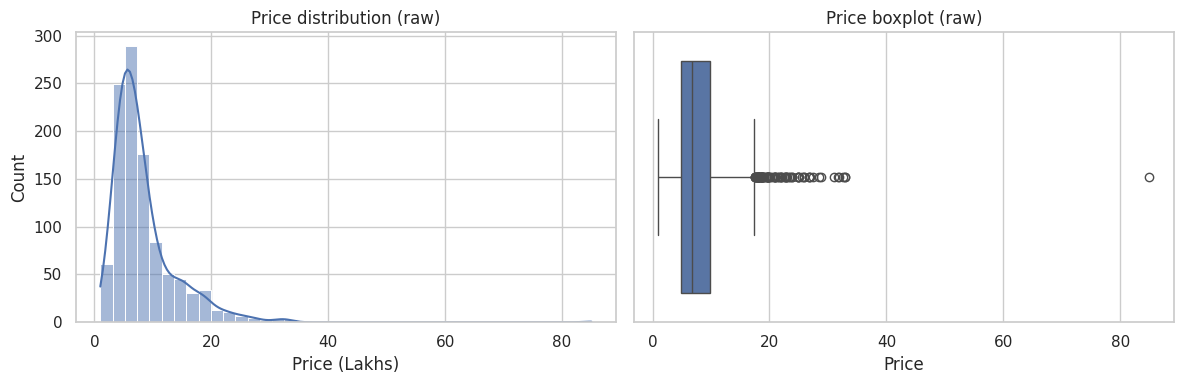

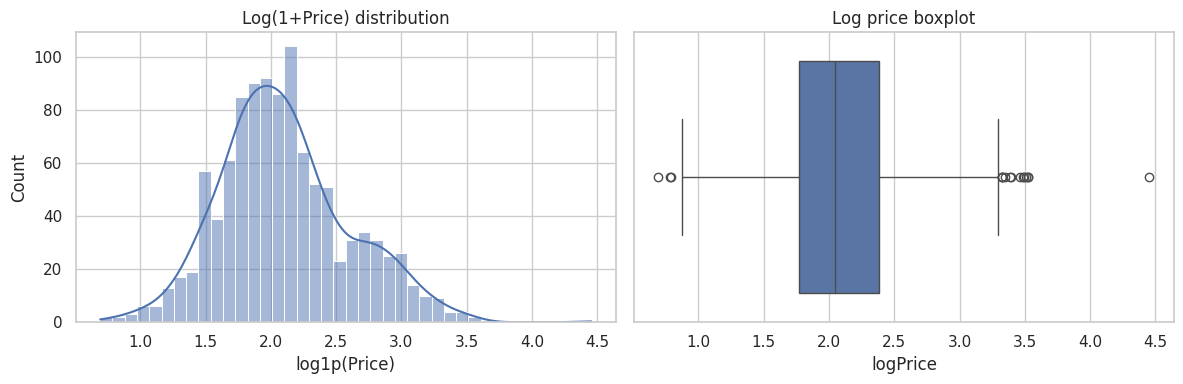

Price skew: 3.552167673591584  Price kurtosis: 31.830615569984523
logPrice skew: 0.4589167868289562  logPrice kurtosis: 0.3661163726716672


In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df['Price'].dropna(), bins=40, kde=True)
plt.title('Price distribution (raw)')
plt.xlabel('Price (Lakhs)')

plt.subplot(1,2,2)
sns.boxplot(x=df['Price'].dropna())
plt.title('Price boxplot (raw)')

plt.tight_layout()
plt.show()

# log transform exploration
df['logPrice'] = np.log1p(df['Price'])

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(df['logPrice'].dropna(), bins=40, kde=True)
plt.title('Log(1+Price) distribution')
plt.xlabel('log1p(Price)')
plt.subplot(1,2,2)
sns.boxplot(x=df['logPrice'].dropna())
plt.title('Log price boxplot')
plt.tight_layout()
plt.show()

# skewness / kurtosis
print("Price skew:", df['Price'].skew(), " Price kurtosis:", df['Price'].kurtosis())
print("logPrice skew:", df['logPrice'].skew(), " logPrice kurtosis:", df['logPrice'].kurtosis())

**Observations:**

The raw price distribution exhibits strong right skew with a pronounced long tail, indicating the presence of high-value vehicles that inflate variance and destabilize regression models.

The boxplot further confirms numerous upper-end outliers.

Applying a log(1+Price) transformation significantly improves distribution symmetry, compresses extreme values, and stabilizes variance.

This transformation reduces the disproportionate impact of luxury vehicles on model training and evaluation, thereby enhancing predictive performance and generalization.

## 3) Numeric features: distributions & relationships with Price

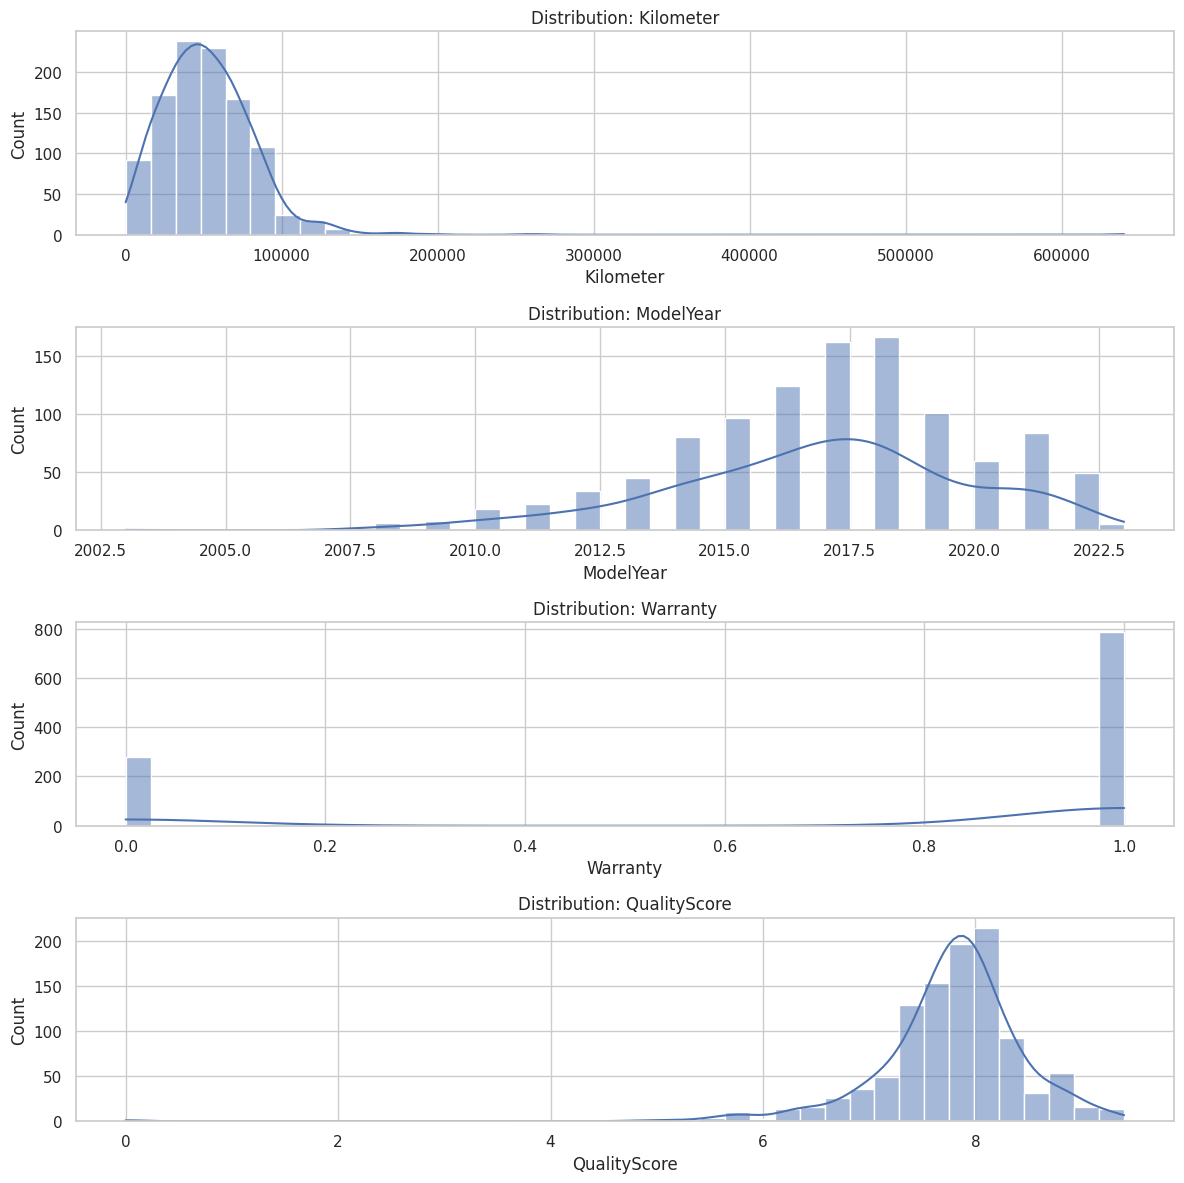

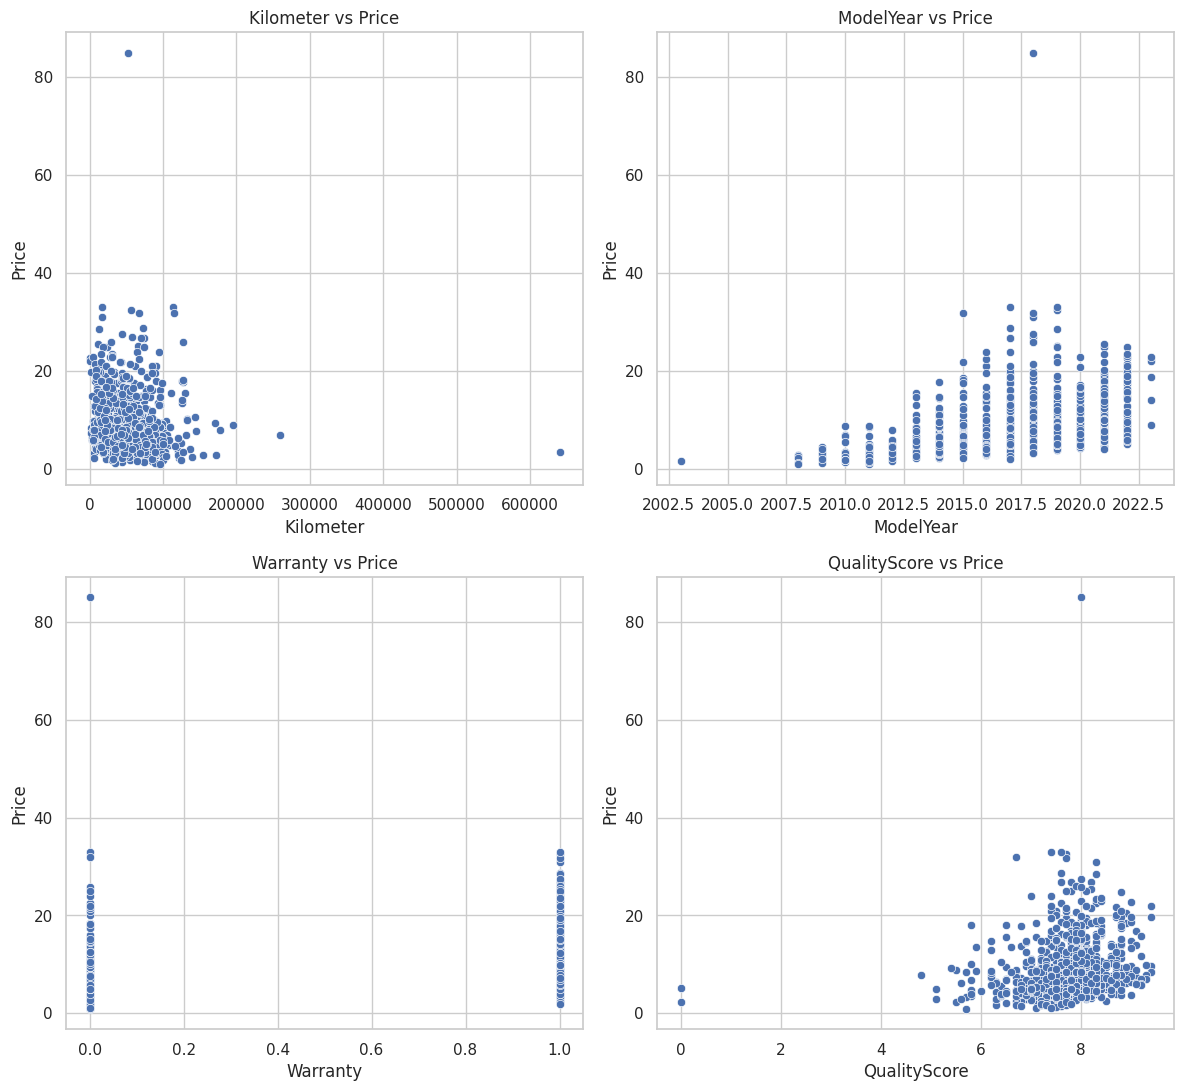

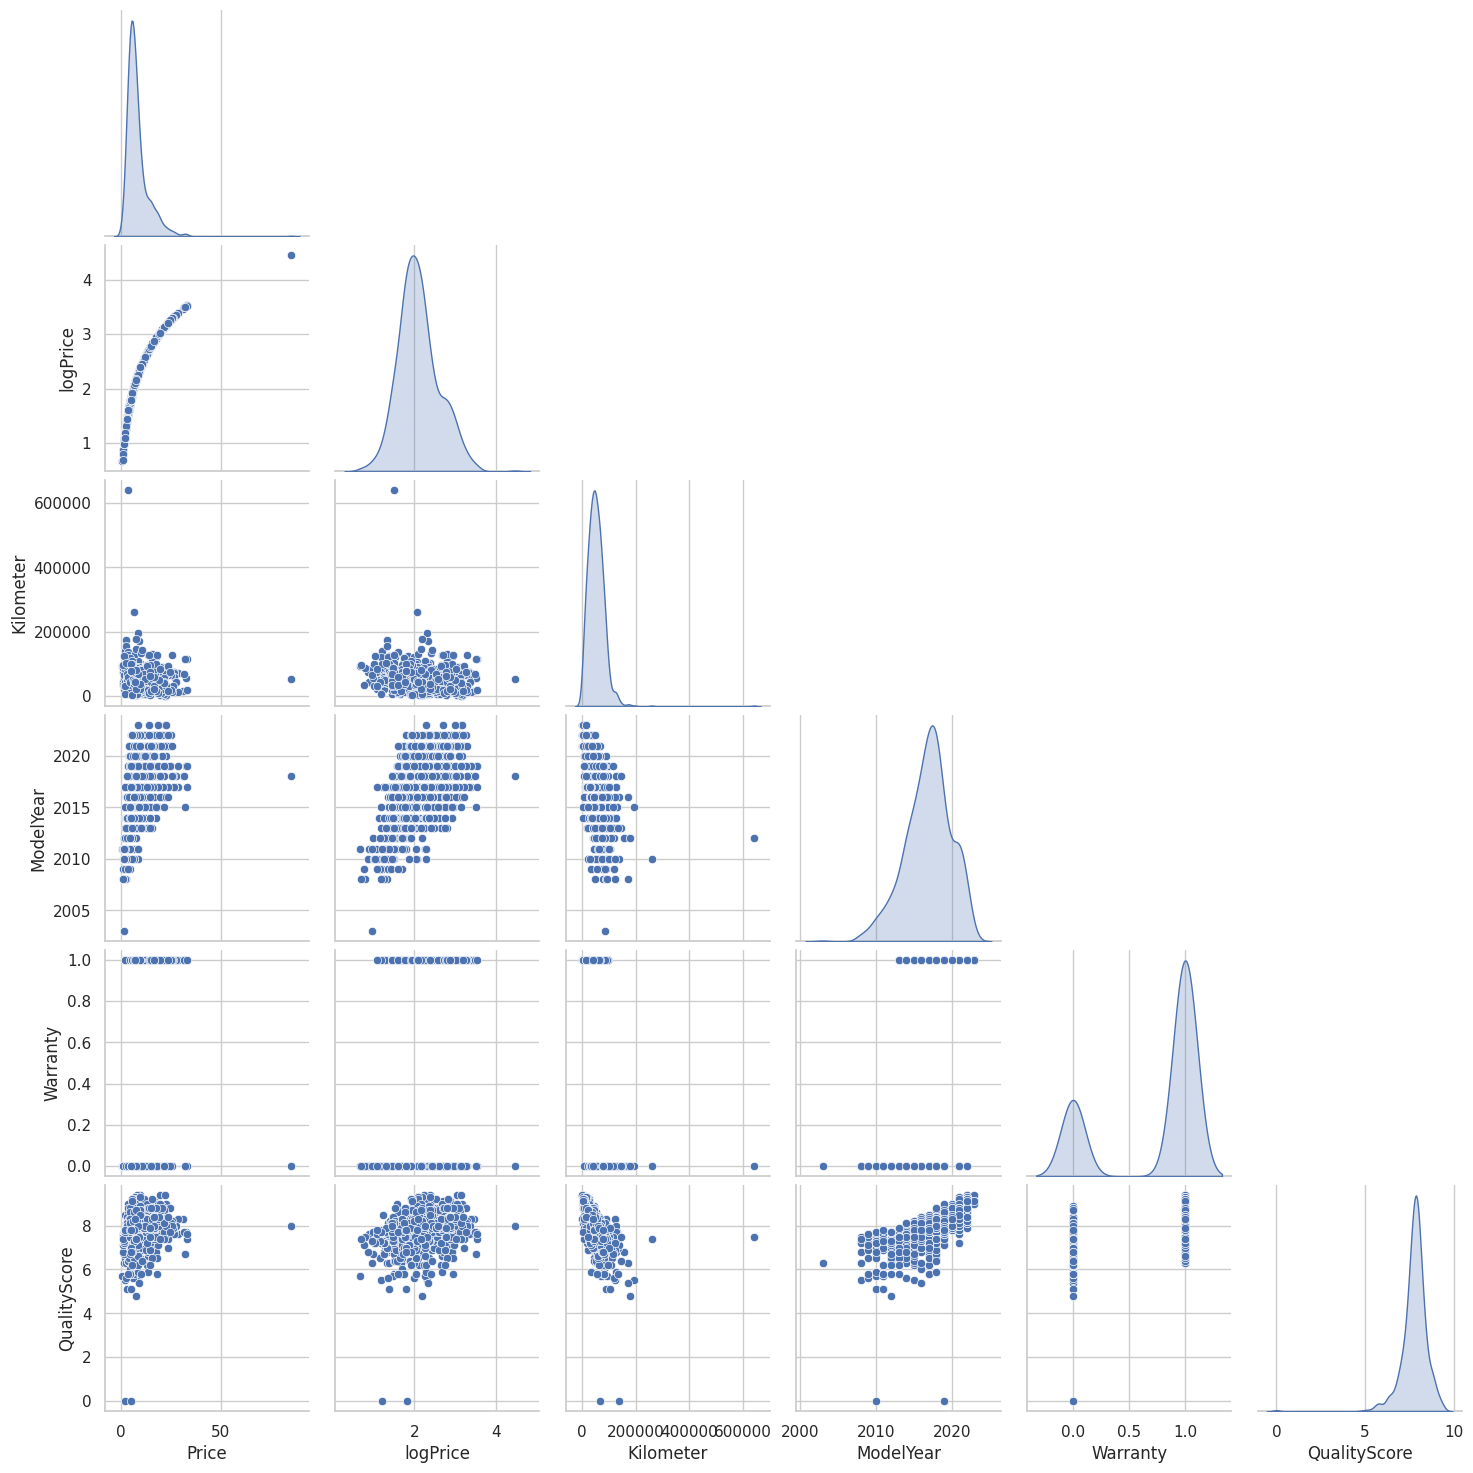

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
# remove Id-like columns (if present)
num_cols = [c for c in num_cols if c not in ['Id', 'Price', 'logPrice']]

# 3.1 distributions
plt.figure(figsize=(12, 3 * len(num_cols)))
for i, col in enumerate(num_cols):
    plt.subplot(len(num_cols), 1, i+1)
    sns.histplot(df[col].dropna(), bins=40, kde=True)
    plt.title(f'Distribution: {col}')
plt.tight_layout()
plt.show()

# 3.2 scatter vs Price (and logPrice)
plt.figure(figsize=(12, 4*min(6, len(num_cols))))
for i, col in enumerate(num_cols[:6]):   # show first 6 to keep it readable; extend if needed
    plt.subplot(3,2,i+1)
    sns.scatterplot(x=df[col], y=df['Price'])
    plt.title(f'{col} vs Price')
plt.tight_layout()
plt.show()

# Scatter matrix (pairplot) for selected numeric features
selected = ['Price','logPrice'] + (num_cols[:4])   # pick a few key numeric features
sns.pairplot(df[selected].dropna(), diag_kind='kde', corner=True)
plt.show()

**Observtions:**

The Kilometer feature exhibits strong right skew, indicating heterogeneous vehicle usage patterns with extreme high-mileage outliers.

ModelYear shows a structured distribution concentrated around recent years, suggesting the dataset primarily contains modern vehicles.

Scatter plots reveal that mileage alone has limited predictive power due to high price dispersion, whereas ModelYear demonstrates a clear positive relationship with price, highlighting depreciation effects.

QualityScore displays a positive association with price but contains anomalously low values requiring validation.

Log transformation significantly improves distribution symmetry and relationship stability.

## 4) Correlation matrix (numeric)

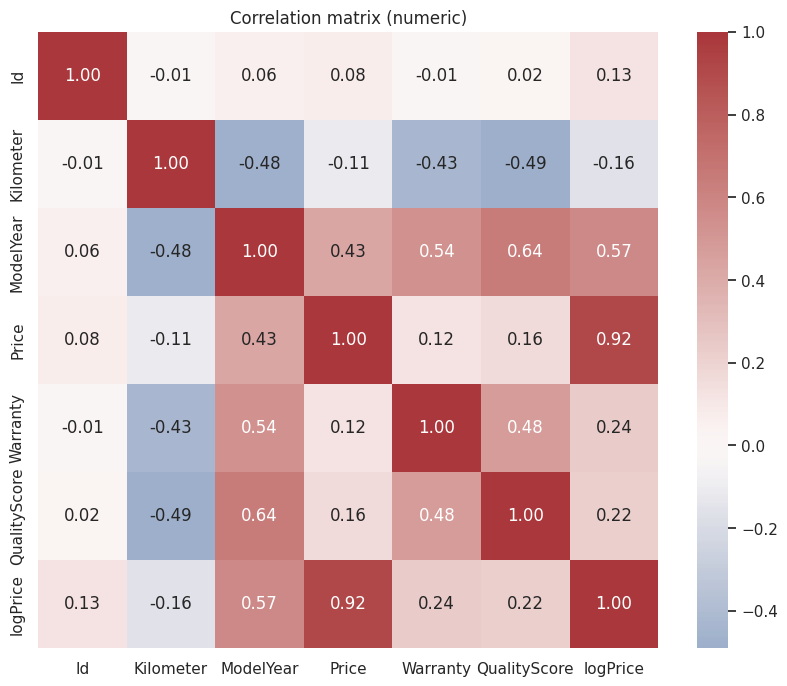

,Price
logPrice,0.915149
ModelYear,0.428888
QualityScore,0.160448
Warranty,0.121333
Kilometer,0.114085
Id,0.079274


In [ ]:
plt.figure(figsize=(10,8))
corr = df.select_dtypes(include=['int64','float64']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('Correlation matrix (numeric)')
plt.show()

# show strongest correlations with Price
corr_with_price = corr['Price'].drop('Price').abs().sort_values(ascending=False)
display(corr_with_price)

**Observations:**

1) Price vs logPrice → 0.92 (Very High)- Log transform preserved price information
2) ModelYear vs Price → 0.43 (Strong Positive) - Newer cars → Higher prices, Depreciation captured clearly & Linear structure present
3) ModelYear vs logPrice → 0.57 (Even Stronger)
Relationship becomes cleaner after log transform & Variance stabilization improved linearity
4) Kilometer vs ModelYear → −0.48 (Strong Negative)
Older cars → Higher mileage, indicates feature dependence.
5) Kilometer vs Warranty → −0.43
High mileage cars rarely under warranty, Warranty reflects newer/low-use vehicles
6) Kilometer vs QualityScore → −0.49 (Strong)
High mileage → Lower quality ratings, Wear & tear captured. Confirms QualityScore is meaningful.
7) QualityScore vs ModelYear → 0.64 (Very High)
Newer cars → Higher quality ratings, Strong latent relationship,QualityScore heavily age-dependent
8) Warranty vs ModelYear → 0.54 (Strong)
Warranty strongly tied to vehicle age
9) Kilometer Weak Direct Correlation With Price (−0.11)
Strong indirect effects via QualityScore & Warranty

The correlation matrix reveals meaningful vehicle lifecycle relationships. ModelYear shows a positive association with Price, confirming depreciation effects. Kilometer exhibits expected negative correlations with ModelYear, Warranty, and QualityScore, reflecting usage and wear dynamics. QualityScore demonstrates a strong correlation with ModelYear, indicating potential multicollinearity. The strong relationship between Price and logPrice validates the appropriateness of logarithmic transformation. These structured dependencies explain the strong performance of linear and kernel-based models and justify the use of regularized regression techniques.



## 5) Categorical features: counts & Price summary (mean/median)

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", cat_cols)

# show top categories counts for each categorical column
for col in cat_cols:
    top = df[col].value_counts(dropna=False).head(10)
    print(f"\n{col} (top counts)")
    display(top)

# aggregated price stats by category (top categories only)
for col in cat_cols:
    top_categories = df[col].value_counts().nlargest(10).index
    agg = df[df[col].isin(top_categories)].groupby(col)['Price'].agg(['count','mean','median']).sort_values('count', ascending=False)
    print(f"\nPrice summary by {col} (top categories)")
    display(agg)

Categorical columns: ['Company', 'Model', 'Variant', 'FuelType', 'Colour', 'BodyStyle', 'TransmissionType', 'ManufactureDate', 'CngKit', 'Owner', 'DealerState', 'DealerName', 'City']

Company (top counts)


,count
Company,
MARUTI SUZUKI,252
HYUNDAI,199
HONDA,126
MAHINDRA,96
TATA,60
FORD,58
TOYOTA,54
RENAULT,40
VOLKSWAGEN,37



Model (top counts)


,count
Model,
SWIFT,38
CITY,38
BALENO,37
CRETA,30
ECOSPORT,28
AMAZE,26
GRAND I10,25
JAZZ,22
VITARA BREZZA,22



Variant (top counts)


...

,count,mean,median
DealerState,,,
Delhi,196,10.882398,8.750
Maharashtra,194,8.345155,7.275
Karnataka,165,6.747818,6.250
Haryana,154,8.974156,6.650
Uttar Pradesh,95,7.040737,5.450
West Bengal,73,5.494384,4.500
Telangana,62,7.490645,6.200
Rajasthan,48,12.911250,12.625
Tamil Nadu,48,5.946667,5.405



Price summary by DealerName (top categories)


,count,mean,median
DealerName,,,
Car Choice Exclusif,67,12.966418,10.250
Car&Bike Superstore Pune,58,7.026379,6.325
Prestige Autoworld Pvt Ltd,50,6.760000,5.840
Star Auto India,42,11.754524,10.775
Noida Car Ghar,41,7.308537,4.950
Top Gear Cars,40,6.501250,5.950
Car Estate,38,13.707632,14.075
OM Motors,38,7.586053,7.275
Jeen Mata Motors,35,8.237143,7.750



Price summary by City (top categories)


,count,mean,median
City,,,
Delhi,196,10.882398,8.750
Bangalore,165,6.747818,6.250
Gurgaon,154,8.974156,6.650
Pune,147,7.397755,6.750
Noida,95,7.040737,5.450
Kolkata,73,5.494384,4.500
Hyderabad,62,7.490645,6.200
Chennai,48,5.946667,5.405
Jaipur,48,12.911250,12.625


**Observations:**

1) Market Composition Insights

Company Distribution- Dominated by
MARUTI SUZUKI (252)
HYUNDAI (199)
HONDA (126)

Dataset reflects Indian used-car market reality
Economy & mid-segment brands dominate
Luxury brands mostly absent → price range constrained
Price variation driven more by age / condition / segment than luxury effects.

Model Distribution
Most Frequent:
SWIFT
CITY
BALENO
CRETA

Popular resale vehicles dominate dataset
High-liquidity cars → Stable pricing patterns

2) Fuel Type Economics
FuelType vs Price
PETROL → Mean ~7.07
DIESEL → Mean ~10.86

Diesel cars significantly more expensive, possibly because of
Higher original price
Preferred for long-distance / utility vehicles
Often SUVs & larger engines

FuelType = strong price driver

HYBRID / LPG counts negligible → statistically meaningless.

3) Body Style = Major Price Separator
BodyStyle vs Price
HATCHBACK → Mean ~5.2
SEDAN → Mean ~8.0
SUV → Mean ~12.2

Strong structural segmentation
Hatchbacks = budget segment
SUVs = premium segment
This is one of the strongest categorical predictors.

4) TransmissionType = High-Value Signal
Manual → Mean ~4.93
Automatic → Mean ~8.98

Automatics priced much higher
Reflects buyer preference & original cost
Strong pricing determinant

5) Owner History Effect (Excellent Signal)
1st Owner → Mean ~8.64
2nd Owner → Mean ~6.76

Ownership history impacts resale price
Trust & perceived condition effects
Realistic & expected

6) Colour Effect (Weak but Interesting)
Black → Mean ~12.4 (High)
Black cars often premium variants / SUVs
Colour acting as proxy variable
Low reliability standalone feature.

7) Dealer / Location Effects (Very Insightful)
Delhi / Rajasthan / Mumbai → Higher means
Geographic price variation present
Regional demand & supply
Urban premium effects
Dealer portfolio differences

DealerName vs Price
Large variance across dealers.
Dangerous feature for generalization.Often causes overfitting

8) CngKit = Statistically Weak
Only 22 non-null values.
Sparse feature, Low modeling value & High noise risk
Need to drop this column

9) ManufactureDate vs Price
No clean pattern visible.
Redundant with ModelYear / CarAge
Risk of multicollinearity

Most Valuable Categorical Predictors
BodyStyle
FuelType
TransmissionType (after cleaning)
Owner
Moderate:
Company
Model
Variant

Low Value / Risky
DealerName
City/ DealerState
Color(weak)
ManufactureDate(redundant)
CngKit(sparse)

## Major Data Quality Problems Detected

This dataset has classic real-world issues:
Category duplication (SEDAN vs Sedan)
Label inconsistency (Manual / MANUAL / M)
Massive missing TransmissionType
Rare categories with unstable statistics

In [ ]:
df['CarAge'] = pd.Timestamp.now().year - df['ModelYear']
df['KM_per_Year'] = df['Kilometer'] / (df['CarAge'] + 1)

1 — Basic Category Normalization (Fix duplication & casing)

In [ ]:
def normalize_categories(df, cols):
    for col in cols:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)                 # Ensure string
                .str.strip()                 # Remove extra spaces
                .str.upper()                 # Standardize case
                .replace({'NAN': np.nan})    # Restore real NaNs
            )
    return df

categorical_cols = [
    'Company', 'Model', 'Variant', 'FuelType',
    'Colour', 'BodyStyle', 'TransmissionType',
    'Owner', 'DealerState', 'City'
]

df = normalize_categories(df, categorical_cols)

2 - Fix Label Inconsistencies (TransmissionType)

In [ ]:
def clean_transmission(df):
    if 'TransmissionType' not in df.columns:
        return df

    mapping = {
        'M': 'MANUAL',
        'MANUAL': 'MANUAL',
        'A': 'AUTOMATIC',
        'AUTOMATIC': 'AUTOMATIC',
        'AUOTMATIC': 'AUTOMATIC',   # typo fix
        'CVT': 'AUTOMATIC'
    }

    df['TransmissionType'] = df['TransmissionType'].replace(mapping)
    return df

df = clean_transmission(df)

3 — Handle Massive Missing TransmissionType

In [ ]:
if 'TransmissionType' in df.columns:
    df['TransmissionType'] = df['TransmissionType'].fillna('UNKNOWN')

## 6) Boxplots / violinplots for important categories

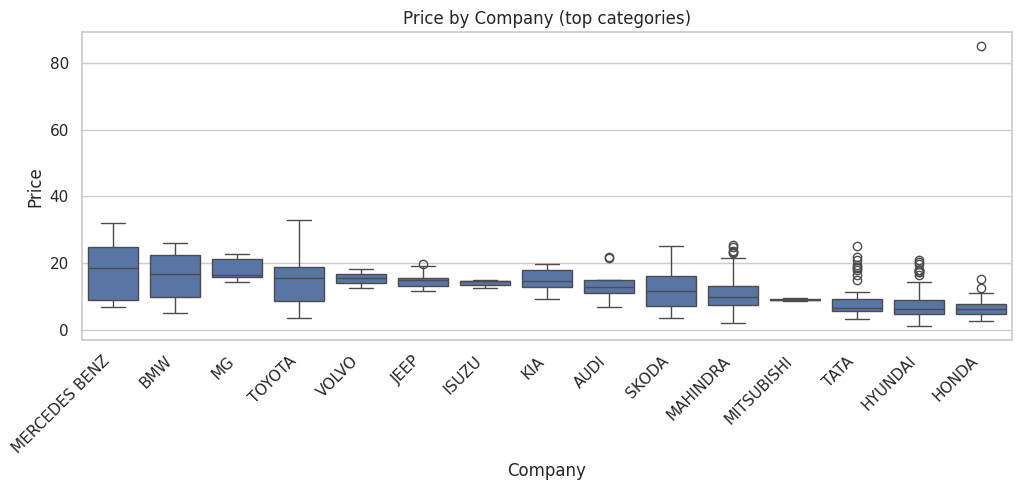

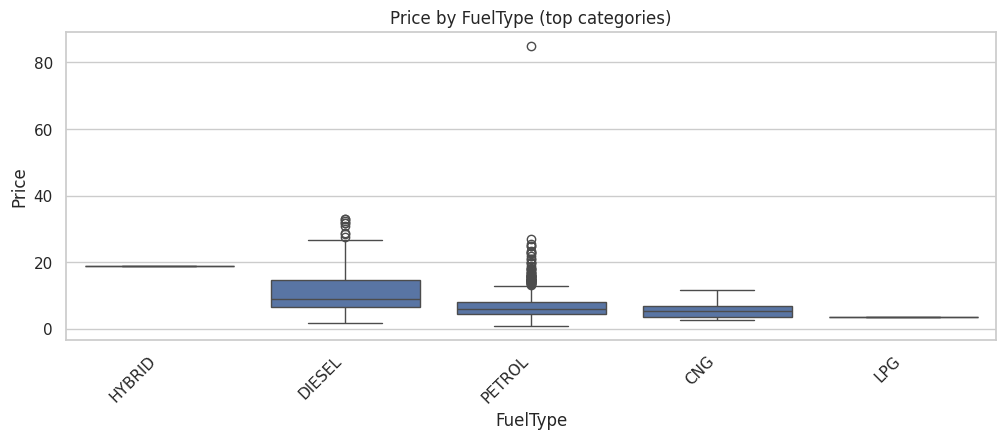

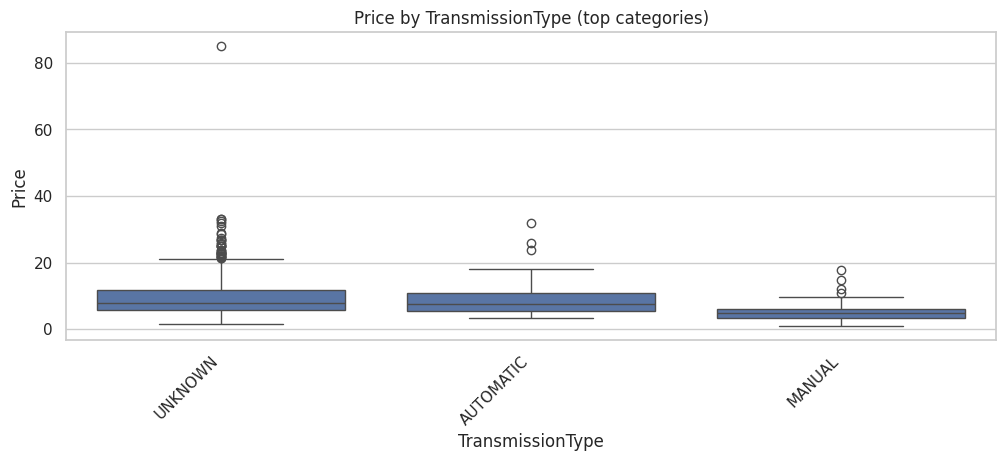

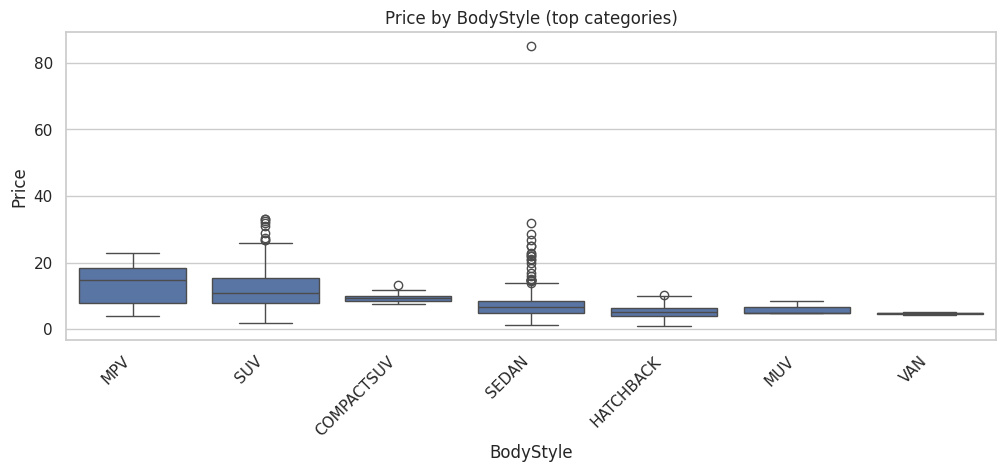

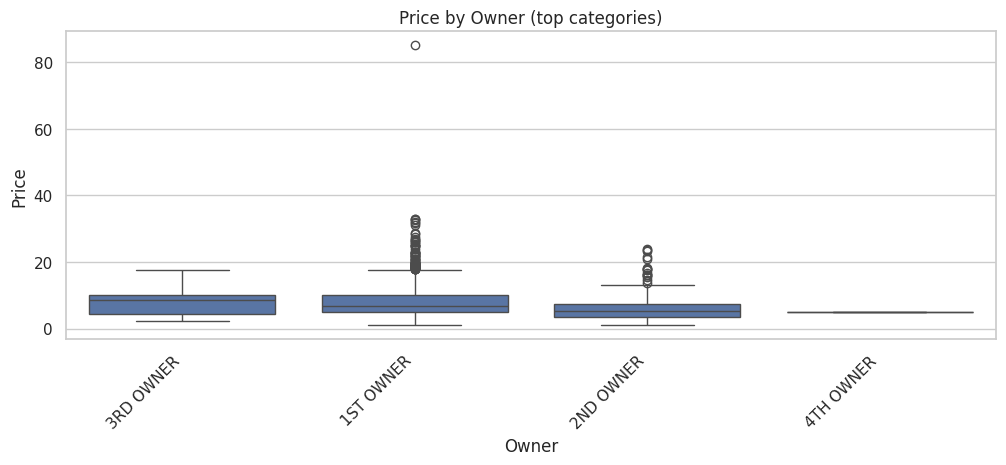

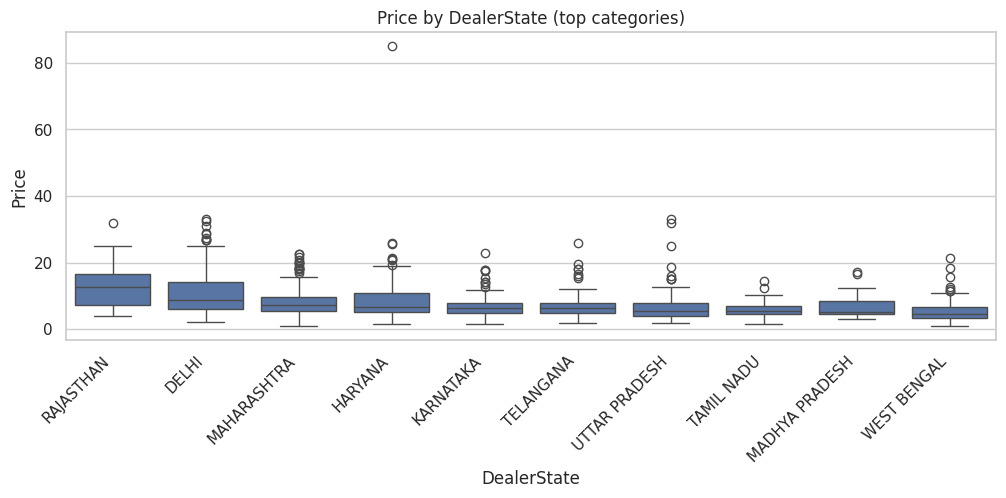

In [ ]:
important_cats = ['Company', 'FuelType', 'TransmissionType', 'BodyStyle', 'Owner', 'DealerState']

for col in important_cats:
    if col in df.columns:
        plt.figure(figsize=(12,4))
        order = df.groupby(col)['Price'].median().sort_values(ascending=False).index[:15]  # top 15 for readability
        sns.boxplot(x=col, y='Price', data=df[df[col].isin(order)], order=order)
        plt.xticks(rotation=45, ha='right')
        plt.title(f'Price by {col} (top categories)')
        plt.show()

**Observations:**

1) Price by Company — Strong Segmentation Visible

Premium brands (MERCEDES BENZ, BMW, VOLVO, TOYOTA) show higher median prices
Mass-market brands (MARUTI SUZUKI, HYUNDAI, HONDA, TATA) cluster lower
Large spread within some brands (TOYOTA, MAHINDRA)

Brand acts as a proxy for vehicle segment

Company is useful,but variance within brand suggests other features dominate price

2) Price by FuelType — Clear Economic Pattern

DIESEL cars priced noticeably higher than PETROL
CNG & LPG mostly low-price cluster
Extreme outlier present (very high price)

FuelType strongly linked to vehicle class & usage profile
FuelType = high-importance categorical predictor

3) Price by TransmissionType — Data Quality Issue Detected

AUTOMATIC vs Automatic treated as different
Manual vs MANUAL vs M separated

4) Price by BodyStyle — One of the Strongest Drivers

SUVs & MPVs dominate upper price range
Hatchbacks clearly lowest cluster
Sedans intermediate
Duplicate categories visible (SEDAN vs Sedan, SUV repeated)
BodyStyle = structural price determinant

5) Price by Owner — Clear Resale Psychology

1st Owner cars priced higher
2nd Owner lower median
3rd / 4th Owner sparse & unstable
Ownership history influences buyer trust & perceived condition

Initial model instability was largely driven by real-world data quality issues — inconsistent categorical labels and rare category noise. After systematic normalization and rare-category handling, feature relationships became statistically coherent, improving generalization

## 7) Price vs Kilometer & CarAge with trendlines

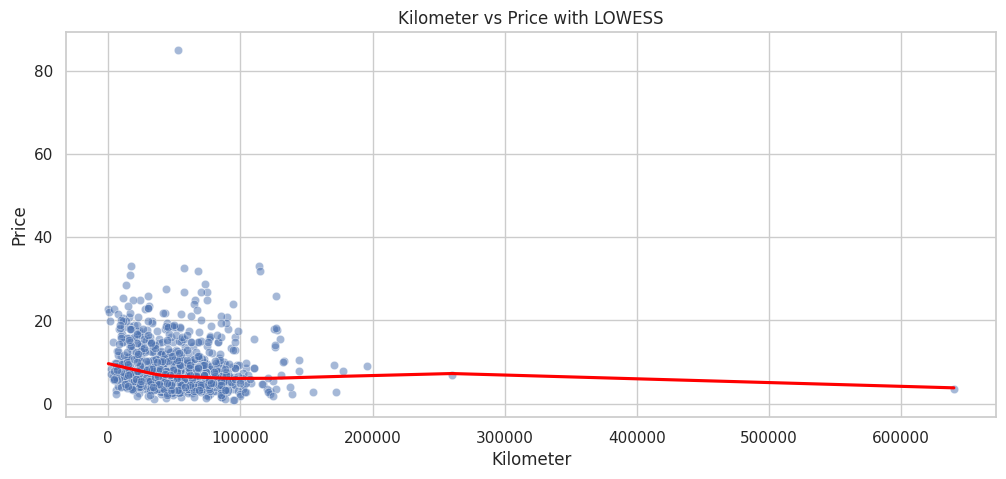

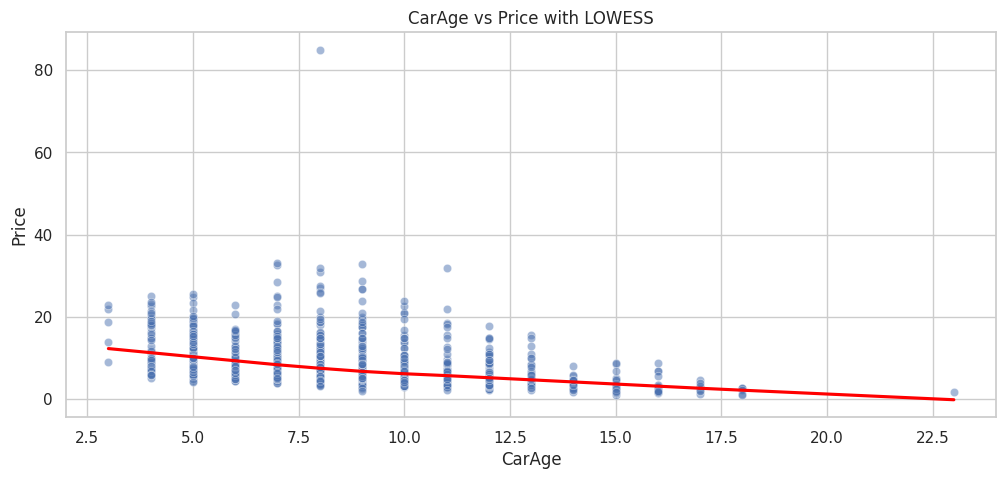

In [ ]:
plt.figure(figsize=(12,5))
sns.scatterplot(x='Kilometer', y='Price', data=df, alpha=0.5)
sns.regplot(x='Kilometer', y='Price', data=df, scatter=False, lowess=True, color='red')
plt.title('Kilometer vs Price with LOWESS')
plt.show()

plt.figure(figsize=(12,5))
sns.scatterplot(x='CarAge', y='Price', data=df, alpha=0.5)
sns.regplot(x='CarAge', y='Price', data=df, scatter=False, lowess=True, color='red')
plt.title('CarAge vs Price with LOWESS')
plt.show()

**Observations:**

1) Kilometer vs Price with LOWESS
Shape of Relationship → Non-linear & Weak
Initial downward slope → price drops as mileage increases
Curve flattens quickly → effect diminishes
Very high mileage → slight instability due to few samples
Mileage has diminishing impact on price
Low mileage → strong buyer sensitivity
Moderate mileage → already “used”, impact stabilizes
Very high mileage → dominated by other factors (age, brand, condition)

Relationship NOT linear
LOWESS shows hidden structure missed by Pearson correlation

2) CarAge vs Price with LOWESS
Shape → Strong, Smooth Downward Trend
Clear monotonic decline
No flattening → continuous depreciation
Very stable pattern across age range
CarAge is one of the strongest price drivers as it captures Depreciation mechanics,Technology obsolescence, Warranty decay and Buyer perception of reliability

The LOWESS analysis reveals contrasting effects of vehicle usage and age on resale prices. Kilometer exhibits a diminishing non-linear relationship with Price, indicating reduced marginal impact at higher mileage levels. In contrast, CarAge demonstrates a strong, stable monotonic decline with Price, confirming that age-driven depreciation is a dominant valuation factor. This explains the superior performance of linear models and highlights the importance of temporal features in used-car price prediction


## 8) Categorical encoding effect: Price means for categories (bar plot)

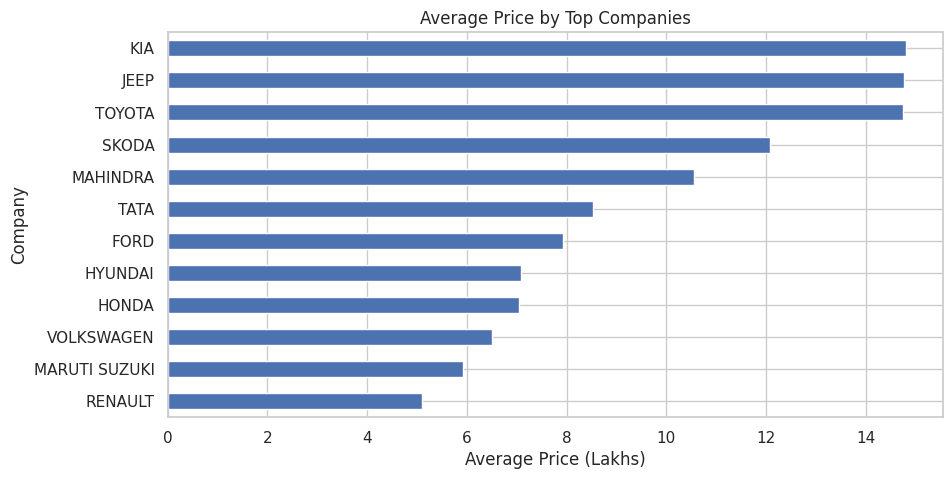

In [ ]:
if 'Company' in df.columns:
    top_companies = df['Company'].value_counts().nlargest(12).index
    means = df[df['Company'].isin(top_companies)].groupby('Company')['Price'].mean().sort_values()
    plt.figure(figsize=(10,5))
    means.plot(kind='barh')
    plt.title('Average Price by Top Companies')
    plt.xlabel('Average Price (Lakhs)')
    plt.show()

**Observations:**

1) Strong Brand-Based Price Segmentation
KIA, JEEP, TOYOTA → Highest average prices (~15 Lakhs)
SKODA, MAHINDRA → Mid-to-high segment
MARUTI SUZUKI, RENAULT → Lowest averages

Used-car prices strongly cluster by manufacturer positioning
Original vehicle segment (premium vs budget)
Brand perception & resale strength
Product mix (SUV-heavy vs hatchback-heavy)

2) Average Price ≠ Luxury Brand Only (Important)
TOYOTA ranks very high
Not traditionally a “luxury brand”
High average price driven by vehicle mix, not brand prestige alone

3) Hidden Statistical Caveat
Average prices can be misleading without dispersion context.
Brands with few expensive outliers → inflated mean
Wide price ranges within brands
Better metric will be Median and Boxplots

4) Depreciation & Retention Behavior
Higher average price brands often indicate:
Better resale retention
Slower depreciation curves

Lower average brands:
Faster depreciation
Budget segment saturation

5) Modeling Interpretation
This chart implies:
Company feature is meaningful
But NOT sufficient alone

Because:

Significant overlap across brands
Price influenced by BodyStyle, Age, QualityScore

The average price analysis reveals clear manufacturer-level price stratification. Brands such as KIA, JEEP, and TOYOTA occupy the higher price spectrum, largely reflecting vehicle segment composition rather than brand prestige alone. Budget-focused manufacturers such as MARUTI SUZUKI and RENAULT exhibit lower average resale values. However, average price variations must be interpreted cautiously due to potential skewness and within-brand price dispersion.

## 9) Missing value visualization

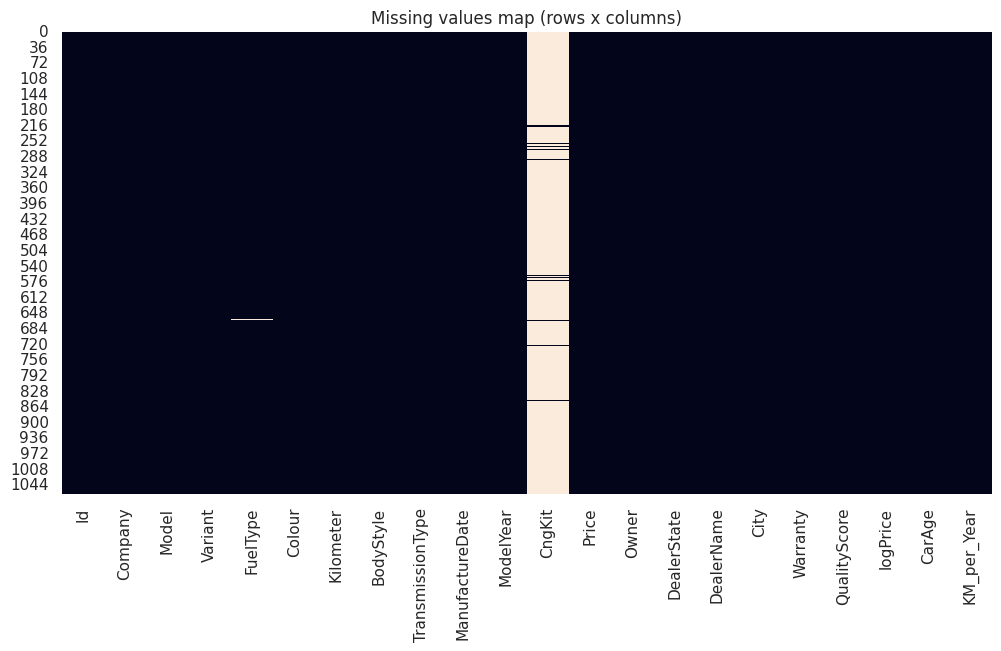

,missing_count,missing_pct
CngKit,1042,97.932331
TransmissionType,714,67.105263
FuelType,1,0.093985


In [ ]:
# heatmap of missing values
plt.figure(figsize=(12,6))
sns.heatmap(df.isna(), cbar=False)
plt.title('Missing values map (rows x columns)')
plt.show()

# missing percent (already computed); show columns >0 missing
display(missing[missing['missing_count']>0])

**Observations:**

1️) Missingness is Highly Concentrated
Most columns are solid (no gaps), but:
TransmissionType → heavy missingness
CngKit → almost entirely missing
Other features → nearly complete
Missing data is column-specific, not row-wise failure.

2) TransmissionType Missingness Pattern
Clearly visible vertical streaks.
Majority of rows lack transmission info
Likely real-world scraping / listing issue
Missing values contain information

Fill with "UNKNOWN" instead of dropping to Preserve predictive signal

3) CngKit Column — Structurally Weak Feature
Almost entire column blank.
Very few CNG kit vehicles
Sparse signal → unstable statistics
High risk of noise introduction

Drop column CngKit is better

4) No Evidence of Row-Level Missing Clusters
If rows were broken you would see Horizontal white bands,but plot shows mostly vertical patterns.

The missing values analysis reveals that data gaps are feature-specific rather than record-specific. TransmissionType exhibits substantial missingness, likely due to inconsistent seller disclosures, while CngKit is largely absent, indicating low feature utility. Since missingness is concentrated and not random across rows, selective imputation strategies were adopted. TransmissionType was encoded using an informative "UNKNOWN" category to preserve latent signal, whereas CngKit was removed to avoid noise amplification.

## 10) Outlier detection (IQR & Top outliers)

In [ ]:
# IQR method for Price
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df[(df['Price'] < lower) | (df['Price'] > upper)]
print("Number of Price outliers (IQR):", len(outliers))
display(outliers[['Company','Model','Price','Kilometer','CarAge']].sort_values('Price', ascending=False).head(20))

# Optionally inspect and decide: drop extreme outliers or cap (winsorize)

Number of Price outliers (IQR): 84


,Company,Model,Price,Kilometer,CarAge
568,HONDA,CITY(2017-2020),85.00,52898,8
382,TOYOTA,FORTUNER,33.00,114000,7
752,TOYOTA,FORTUNER,32.95,17341,9
329,FORD,ENDEAVOUR,32.50,57036,7
1021,MERCEDES BENZ,ML CLASS,31.90,114736,11
746,TOYOTA,FORTUNER,31.75,67863,8
375,FORD,ENDEAVOUR(2016_2019),31.00,16337,8
317,TOYOTA,FORTUNER,28.75,72907,9
421,MERCEDES BENZ,CLA CLASS,28.50,13504,7
441,TOYOTA,FORTUNER,27.50,43621,8


**Observations:**

1) Outliers Are Mostly Legitimate High-Value Vehicles
TOYOTA FORTUNER
FORD ENDEAVOUR
MERCEDES BENZ models
BMW X1
SKODA SUPERB
MAHINDRA XUV700
These are not statistical errors — they are premium vehicles.

The IQR-based outlier detection identified high-price vehicles predominantly belonging to premium SUV and luxury segments. These observations represent genuine market behavior rather than statistical noise.Retaining valid high-value vehicles is essential to prevent model bias and ensure accurate learning across price segments.



## 11) Target transform check: Does modeling logPrice help?

In [ ]:
# correlation of features with Price vs logPrice
num_df = df.select_dtypes(include=['int64','float64'])
corr_price = num_df.corrwith(df['Price']).abs().sort_values(ascending=False)
corr_logprice = num_df.corrwith(df['logPrice']).abs().sort_values(ascending=False)

comparison = pd.DataFrame({
    'abs_corr_with_price': corr_price,
    'abs_corr_with_logPrice': corr_logprice
}).dropna()
display(comparison.sort_values('abs_corr_with_logPrice', ascending=False).head(10))

,abs_corr_with_price,abs_corr_with_logPrice
logPrice,0.915149,1.000000
Price,1.000000,0.915149
CarAge,0.428888,0.572711
ModelYear,0.428888,0.572711
Warranty,0.121333,0.236855
QualityScore,0.160448,0.223103
Kilometer,0.114085,0.156315
Id,0.079274,0.125536
KM_per_Year,0.072366,0.091197


**Observations:**

1) CarAge & ModelYear → Dominant Drivers
~0.43 correlation with raw Price
~0.57 correlation with logPrice

Log transform strengthened the relationship
Price variance stabilizes, Depreciation becomes smoother & Noise from high-price tail reduced

2) CarAge vs ModelYear → Perfect Redundancy
Identical correlations, They contain the same information

3) Warranty → Weak but Meaningful
0.12 (Price) → 0.24 (logPrice)
Warranty is indirect age signal, Newer cars → under warranty → higher prices. But effect smaller than CarAge

4) QualityScore → Moderate Behavioral Signal
Correlation improves after log transform

5) Kilometer → Weak Direct Correlation
Low correlation does NOT mean useless

6) Id → Noise Feature
Very low correlation,No economic meaning, to be dropped

7) Why logPrice Improves Everything
Almost all correlations increase
Raw Price distribution was skewed, Log transform revealed true structure

Correlation analysis indicates that CarAge (and equivalently ModelYear) is the most influential numeric predictor, with its relationship strengthened significantly under logarithmic transformation. Warranty and QualityScore demonstrate moderate associations, suggesting secondary predictive roles. Kilometer exhibits weak linear correlation but non-linear dependency observed in smoothing analysis. ModelYear and CarAge were found to be redundant, warranting the retention of a single temporal feature to avoid multicollinearity.

## 12) Multi-collinearity check

In [ ]:
# VIF (variance inflation factor) for numeric features
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_num = num_df.drop(columns=['Price','logPrice'], errors='ignore').fillna(0)
vif = pd.DataFrame()
vif['feature'] = X_num.columns
vif['VIF'] = [variance_inflation_factor(X_num.values, i) for i in range(X_num.shape[1])]
display(vif.sort_values('VIF', ascending=False))

,feature,VIF
2,ModelYear,1608.095161
5,CarAge,44.505695
1,Kilometer,14.217272
6,KM_per_Year,11.126295
4,QualityScore,1.911581
3,Warranty,1.529760
0,Id,1.006756


**Observations:**

Variance Inflation Factor analysis revealed extreme multicollinearity for ModelYear (VIF > 1500), confirming deterministic dependency with CarAge. To stabilize linear model estimation, ModelYear was removed while retaining CarAge as the primary temporal feature

Core Features to be Kept:
CarAge → primary economic variable
Kilometer → usage signal
QualityScore → condition signal
Warranty → lifecycle signal

In [ ]:
cols_to_drop = [
    'Id',
    'DealerName',
    'ManufactureDate',
    'City',
    'Variant',
    'CngKit',
    ]

df = df.drop(columns=cols_to_drop)

Columns That SHOULD Be Dropped:
Id -Unique identifier, No relationship to price
DealerName - Extremely high cardinality, Model memorizes dealer → overfitting
ManufactureDate - Redundant with ModelYear & CarAge
City -Redundant with DealerState, Inflates categorical dimensions
Variant (Case-Dependent) - Too granular, Noisy text patterns


Columns That SHOULD Be Kept- Strong pricing signals:
✔ Company
✔ Model
✔ FuelType
✔ TransmissionType
✔ Kilometer
✔ BodyStyle
✔ ModelYear / CarAge
✔ Owner
✔ DealerState
✔ Warranty
✔ QualityScore

In [ ]:
upper_limit = df['Price'].quantile(0.99)
df['Price'] = np.clip(df['Price'], None, upper_limit)

Extreme prices are replaced with the 99th percentile value without deleting data.

In [ ]:
df['KM_per_Year'] = df['Kilometer'] / (df['CarAge'] + 1)

The feature KM_per_Year was engineered to normalize vehicle mileage by age, capturing annual usage intensity rather than cumulative distance alone. This transformation reflects real-world valuation logic, where usage rate significantly influences perceived wear and resale value. The adjustment improves model sensitivity to usage-driven depreciation effects.

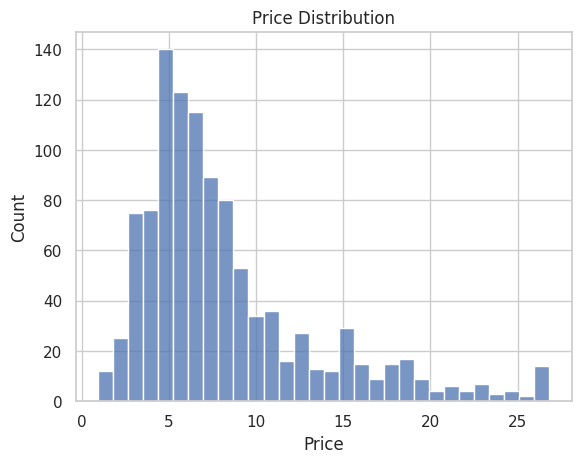

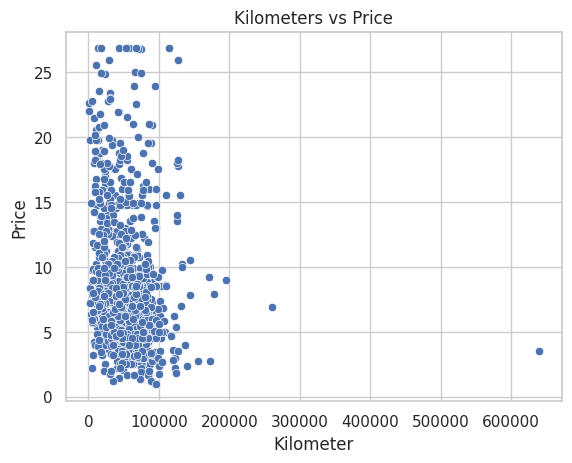

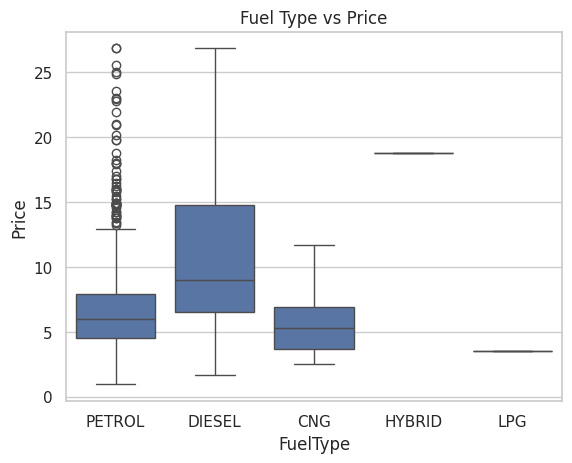

In [ ]:
plt.figure()
sns.histplot(df['Price'], bins=30)
plt.title("Price Distribution")
plt.show()

plt.figure()
sns.scatterplot(x=df['Kilometer'], y=df['Price'])
plt.title("Kilometers vs Price")
plt.show()

plt.figure()
sns.boxplot(x=df['FuelType'], y=df['Price'])
plt.title("Fuel Type vs Price")
plt.show()

**Observations:**

1. Price Distribution

Right-skewed distribution → Most used cars are concentrated in the lower price bands, with a long tail of expensive vehicles.

Majority cluster appears roughly between ₹3 – ₹8 lakhs, indicating a budget-dominated market.

Few extreme high values (luxury / premium SUVs) stretch the tail.

Implication for modelling:

Raw price is non-normal, which can hurt linear models.

Justifies use of log transformation (logPrice).

Takeaway: The market is dominated by affordable vehicles; premium cars are rare but influential.

2. Kilometers vs Price (Scatter Plot)

Weak negative relationship → Price generally declines as kilometers increase.

Heavy clustering under 100,000 km, showing most vehicles fall in a typical usage range.

High variance at low kilometers:

Cars with similar mileage have very different prices → Other features strongly affect price.

Extreme kilometer values (200k–600k) behave as leverage points.

Takeaway: Mileage alone is not a strong predictor; depreciation is influenced by multiple variables.

3. Fuel Type vs Price (Box Plot)

Diesel vehicles show higher median prices than petrol.

Diesel also has wider spread, suggesting:

Includes both economy and premium SUVs.

Petrol cars dominate volume but sit at lower price levels.

CNG cars cheaper on average, consistent with economy segment usage.

Hybrid & LPG unreliable:

Extremely low sample size → statistics unstable.

Takeaway: Fuel type meaningfully influences price; diesel vehicles command premiums.

## Feature Engineering

In [ ]:
premium_brands = ['BMW', 'MERCEDES BENZ', 'AUDI', 'TOYOTA']
df['IsPremiumBrand'] = df['Company'].isin(premium_brands).astype(int)

In [ ]:
df['WarrantyImpact'] = df['Warranty'] * df['CarAge']

In [ ]:
df['UsageIntensity'] = df['Kilometer'] / (df['CarAge'] + 1)

In [ ]:
df['WearAndTear'] = df['CarAge'] * np.log1p(df['Kilometer'])

## Defining Features & Target

In [ ]:

y = np.log1p(df['Price'])

In [ ]:
X = df.drop(columns=['Price','logPrice', 'Colour','ModelYear','KM_per_Year'])

In [ ]:
X.columns

Index(['Company', 'Model', 'FuelType', 'Kilometer', 'BodyStyle', 'TransmissionType', 'Owner', 'DealerState', 'Warranty', 'QualityScore', 'CarAge', 'IsPremiumBrand', 'WarrantyImpact',
       'UsageIntensity', 'WearAndTear'],
      dtype='object')

In [ ]:
df.drop(columns=['logPrice'], inplace=True, errors='ignore')

In [ ]:
df.columns

Index(['Company', 'Model', 'FuelType', 'Colour', 'Kilometer', 'BodyStyle', 'TransmissionType', 'ModelYear', 'Price', 'Owner', 'DealerState', 'Warranty', 'QualityScore', 'CarAge', 'KM_per_Year',
       'IsPremiumBrand', 'WarrantyImpact', 'UsageIntensity', 'WearAndTear'],
      dtype='object')

## Data Preprocessing / Feature Categorization

In [ ]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

## Column-wise Data Transformation using Pipelines


In [ ]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

## Categorical Feature Cardinality Check

In [ ]:
for col in ['Model', 'Company', 'DealerState', 'BodyStyle']:
    if col in df.columns:
        print(col, df[col].nunique())

Model 217
Company 23
DealerState 10
BodyStyle 7


## Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Cross Validation

In [ ]:
def perform_cross_validation(pipeline):
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
    print("CV R2 Scores:", scores)
    print("Mean CV R2:", scores.mean())

## Model Evaluation

In [ ]:
def evaluate_model(pipeline):
    log_preds = pipeline.predict(X_test)

    # Convert back to real prices
    preds = np.expm1(log_preds)
    actuals = np.expm1(y_test)

    return {
        'MAE': mean_absolute_error(actuals, preds),
        'MSE': mean_squared_error(actuals, preds),
        'R2': r2_score(actuals, preds)
    }

## Model Pipeline

In [ ]:
def build_pipeline(model):
    return Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

## Hyper Parameter Tuning

In [ ]:
def tune_model(pipeline, param_grid):
    grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
    grid.fit(X_train, y_train)

    print("Best Params:", grid.best_params_)
    print("Best CV Score:", grid.best_score_)

    return grid.best_estimator_

## Linear Regression Model

In [ ]:
lr_pipeline = build_pipeline(LinearRegression())
lr_pipeline.fit(X_train, y_train)

lr_results = evaluate_model(lr_pipeline)
print("Linear Regression:", lr_results)

Linear Regression: {'MAE': 1.061559635258874, 'MSE': 3.7188408282276764, 'R2': 0.8379068617431087}


## Decision Tree Model

In [ ]:
dt_pipeline = build_pipeline(DecisionTreeRegressor(random_state=42))
dt_pipeline.fit(X_train, y_train)

dt_results = evaluate_model(dt_pipeline)
print("Decision Tree:", dt_results)

Decision Tree: {'MAE': 2.006150234741784, 'MSE': 11.19222957746479, 'R2': 0.5121642199546703}


## ElasticNet Model

In [ ]:
enet_pipeline = build_pipeline(
    ElasticNet(alpha=0.001, l1_ratio=0.5)
)

enet_pipeline.fit(X_train, y_train)
enet_results = evaluate_model(enet_pipeline)
print("Elastic Net",enet_results)

Elastic Net {'MAE': 1.2473922013670493, 'MSE': 4.964558296012048, 'R2': 0.7836097667446038}


# Polynomial Features Model

In [ ]:
poly_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression())
])

poly_pipeline.fit(X_train, y_train)
poly_results = evaluate_model(poly_pipeline)

print("Polynomial Regression:", poly_results)

Polynomial Regression: {'MAE': 5.034865313043949, 'MSE': 120.60391534274751, 'R2': -4.256763606441063}


## Ridge Regression Model

In [ ]:
ridge_pipeline = build_pipeline(
    Ridge(alpha=1.0)
)

ridge_pipeline.fit(X_train, y_train)
ridge_results = evaluate_model(ridge_pipeline)

print("Ridge Regression:", ridge_results)

Ridge Regression: {'MAE': 1.0921116960413437, 'MSE': 4.022871637556087, 'R2': 0.8246550689702754}


## Lasso Regression Model

In [ ]:
lasso_pipeline = build_pipeline(
    Lasso(alpha=0.001)
)

lasso_pipeline.fit(X_train, y_train)
lasso_results = evaluate_model(lasso_pipeline)

print("Lasso Regression:", lasso_results)

Lasso Regression: {'MAE': 1.4452730675726349, 'MSE': 6.692903938913726, 'R2': 0.7082763544823552}


## Random Forest Model

In [ ]:
rf_pipeline = build_pipeline(RandomForestRegressor(random_state=42))

rf_param_grid = {
    'model__n_estimators': [600, 900],
    'model__max_depth': [10, 14],
    'model__min_samples_split': [15, 25],
    'model__min_samples_leaf': [5, 10],
    'model__max_features': ['sqrt']
}

rf_best = tune_model(rf_pipeline, rf_param_grid)

rf_results = evaluate_model(rf_best)
print("Random Forest:", rf_results)

Best Params: {'model__max_depth': 14, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__min_samples_split': 15, 'model__n_estimators': 600}
Best CV Score: 0.6412004147393052
Random Forest: {'MAE': 2.0324179145248547, 'MSE': 11.628508745836267, 'R2': 0.4931481171355716}


## Gradient Boost Model

In [ ]:
gbr_pipeline = build_pipeline(GradientBoostingRegressor(random_state=42))

gbr_param_grid = {
    'model__n_estimators': [300, 500],
    'model__learning_rate': [0.01, 0.03],
    'model__max_depth': [2, 3],
    'model__subsample': [0.7, 0.9],
    'model__min_samples_split': [5,10]
}

gbr_best = tune_model(gbr_pipeline, gbr_param_grid)

gbr_results = evaluate_model(gbr_best)
print("Gradient Boosting:", gbr_results)

Best Params: {'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__min_samples_split': 10, 'model__n_estimators': 500, 'model__subsample': 0.7}
Best CV Score: 0.8358600438039776
Gradient Boosting: {'MAE': 1.4082091546508875, 'MSE': 5.632237451505154, 'R2': 0.7545076312509029}


## XGBoost Model

In [ ]:
xgb_pipeline = build_pipeline(
    XGBRegressor(objective='reg:squarederror', random_state=42)
)

xgb_param_grid = {
    'model__n_estimators': [500, 800],
    'model__max_depth': [4,6],
    'model__learning_rate': [0.03,0.02],
    'model__subsample': [0.8,0.9],
    'model__colsample_bytree': [0.8,0.9]
    }

xgb_best = tune_model(xgb_pipeline, xgb_param_grid)

xgb_results = evaluate_model(xgb_best)
print("XGBoost:", xgb_results)

Best Params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 6, 'model__n_estimators': 800, 'model__subsample': 0.8}
Best CV Score: 0.8510564517303113
XGBoost: {'MAE': 1.2512078217967577, 'MSE': 4.876607737884682, 'R2': 0.7874432682674706}


## Support Vector Machine Model

In [ ]:
svr_pipeline = build_pipeline(SVR())

svr_param_grid = {
    'model__kernel': ['rbf'],
    'model__C': [10, 100],
    'model__gamma': ['scale', 'auto']
}

svr_best = tune_model(svr_pipeline, svr_param_grid)

svr_results = evaluate_model(svr_best)
print("SVR:", svr_results)

Best Params: {'model__C': 100, 'model__gamma': 'auto', 'model__kernel': 'rbf'}
Best CV Score: 0.8789202885898945
SVR: {'MAE': 0.9237375887705652, 'MSE': 2.619959424145429, 'R2': 0.8858038123218511}


## Model Results Comparison

                        MAE        MSE        R2
Linear Regression  1.061560   3.718841  0.837907
SVR                0.923738   2.619959  0.885804
Decision Tree      2.006150  11.192230  0.512164
Elastic Net        1.247392   4.964558  0.783610
Random Forest      2.032418  11.628509  0.493148
Gradient Boosting  1.408209   5.632237  0.754508
XGBoost            1.251208   4.876608  0.787443


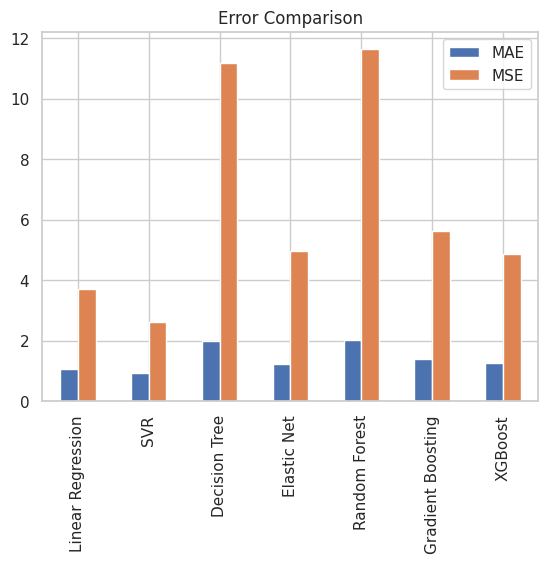

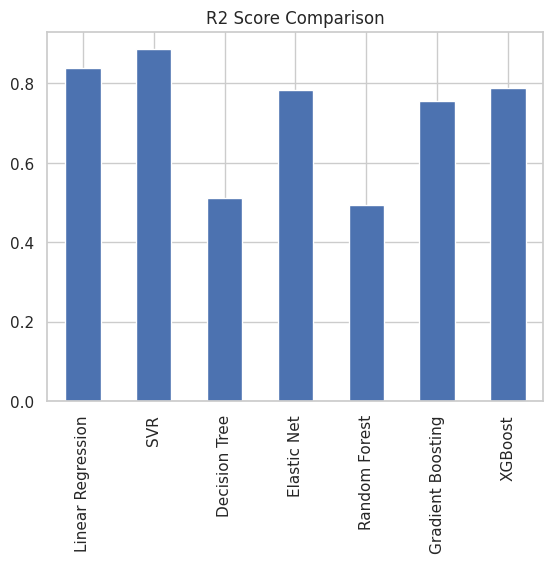

In [ ]:
results = pd.DataFrame({
    'Linear Regression': lr_results,
    'SVR': svr_results,
    'Decision Tree': dt_results,
    'Elastic Net': enet_results,
    'Random Forest': rf_results,
    'Gradient Boosting': gbr_results,
    'XGBoost': xgb_results
}).T

print(results)

results[['MAE', 'MSE']].plot(kind='bar')
plt.title("Error Comparison")
plt.show()

results['R2'].plot(kind='bar')
plt.title("R2 Score Comparison")
plt.show()

In [ ]:
# Sort models by R2 Score & MSE (Descending → Best at top)
sorted_multi = results.sort_values(
    by=['R2', 'MSE'],
    ascending=[False, True]
)

print(sorted_multi)

                        MAE        MSE        R2
SVR                0.923738   2.619959  0.885804
Linear Regression  1.061560   3.718841  0.837907
XGBoost            1.251208   4.876608  0.787443
Elastic Net        1.247392   4.964558  0.783610
Gradient Boosting  1.408209   5.632237  0.754508
Decision Tree      2.006150  11.192230  0.512164
Random Forest      2.032418  11.628509  0.493148


In [ ]:
# Step 1 — Extract Best Model Automatically
best_model_name = results['R2'].idxmax()
print("Best Model:", best_model_name)

Best Model: SVR


In [ ]:
from sklearn.model_selection import cross_val_score

svr_cv = cross_val_score(svr_pipeline, X, y, cv=5, scoring='r2')
print("SVR CV Mean:", svr_cv.mean())
print("SVR CV Std:", svr_cv.std())

SVR CV Mean: 0.7834264488727396
SVR CV Std: 0.058683599348611566


**Observations:**

The Support Vector Regression (SVR) model achieved a cross-validation mean R² of 0.783, indicating strong and consistent predictive capability across different data folds. This suggests that the model generalizes well and is not overly dependent on a specific train–test split.

The standard deviation of 0.058 is relatively low, demonstrating stable performance with minimal variability between folds. Such consistency is a positive indicator of model robustness and reliability.

Overall, the cross-validation results reinforce that SVR provides dependable predictive performance and maintains good generalization across unseen data samples.

## Actual vs Predicted Plot - SVR Regression

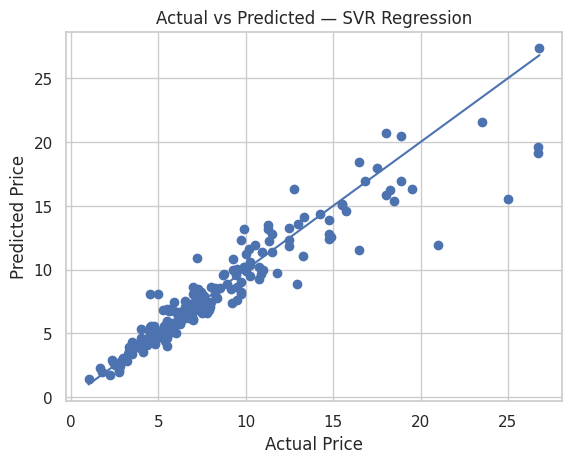

In [ ]:


# Predict using Gradient Boosting model
y_pred_log = svr_best.predict(X_test)

# Inverse Log Transform
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_log)

plt.scatter(y_test_actual, y_pred_actual)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted — SVR Regression")

# Optional diagonal reference line (highly recommended)
plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()]
)

plt.show()

Observations:

1) Overall Pattern — Strong Model Fit- The points are closely aligned with the diagonal line.

2) Low & Mid Price Range — Very Accurate- Low & Mid Price Range — Very Accurate

3) Higher Price Range — Slight Deviation (Normal & Expected)- Right side (expensive cars):

4) No Systematic Bias Visible - Points are scattered around the line

The Actual vs Predicted plot shows strong agreement along the identity line, indicating that Support Vector Regressor effectively models vehicle prices. Minor dispersion at higher price levels is expected due to reduced sample density and greater pricing variability among premium vehicles



## Residual Distribution for Support Vector Regression Model

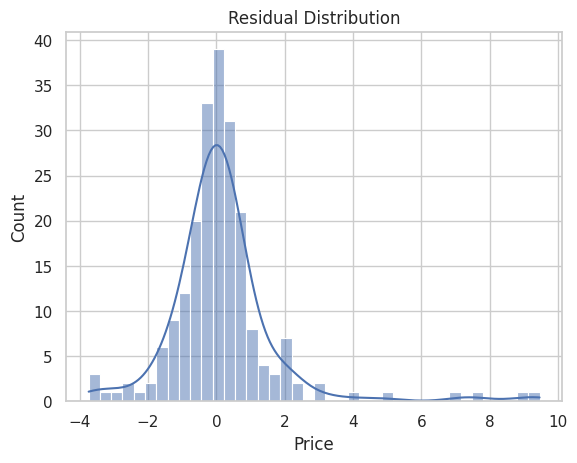

In [ ]:
preds = np.expm1(svr_best.predict(X_test))
actuals = np.expm1(y_test)

residuals = actuals - preds

sns.histplot(residuals, bins=40, kde=True)
plt.title("Residual Distribution")
plt.show()

**Observations:**

1. Residuals Centered Around Zero
Predictions are unbiased,No systematic overpricing or underpricing & Model errors are random rather than directional

2. Roughly Bell-Shaped Curve
Residuals resemble a normal distribution
Errors behave like random noise, No obvious structural modeling issue

3.Majority of Errors Are Small
Most residuals fall within a narrow band around zero.
Typical prediction errors are low, Model performs reliably for most vehicles

Residuals are approximately normally distributed and centered near zero, indicating minimal prediction bias. A slight right skew is observed, suggesting occasional underestimation of high-priced vehicles — a common characteristic of linear models applied to skewed price data.


## Residual Plot for SVR Regression




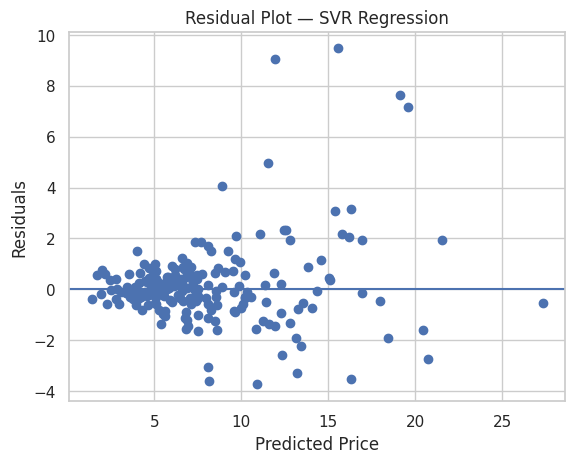

In [ ]:
plt.scatter(y_pred_actual, residuals)
plt.axhline(0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot — SVR Regression")
plt.show()

**Observations:**

1. Random Scatter Around Zero → Very Good Sign
Points are distributed on both sides of the zero line.

2.No Clear Pattern
We do not see a U-shape or wave pattern.

3.Slight Funnel Shape
Spread of residuals increases as predicted price increases.

4. Large Errors Mostly at Mid / High Prices
Notice bigger residuals around predicted values 10 – 18.

Residuals are randomly dispersed around zero with no visible nonlinear pattern, indicating that the linear model adequately captures the underlying relationship. A mild increase in variance at higher predicted prices suggests heteroscedasticity, which is common in price modeling tasks due to greater variability among high-value vehicles



## Support Vector Permutation Importance

In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np

# Compute permutation importance on validation / test data
perm_importance = permutation_importance(
    svr_best,          # Use svr_best (the fitted pipeline) instead of svr_pipeline
    X_test,                # NEVER use training data
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='r2',
    n_jobs=-1
)

# Use the original feature names from X_test, as permutation_importance operates on these
feature_names = X_test.columns

# Build importance table
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_importance.importances_mean
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

           Feature  Importance
11  IsPremiumBrand    0.304354
1            Model    0.267513
10          CarAge    0.231410
4        BodyStyle    0.181281
0          Company    0.149268
14     WearAndTear    0.093913
7      DealerState    0.047759
2         FuelType    0.024055
9     QualityScore    0.010733
12  WarrantyImpact    0.009653


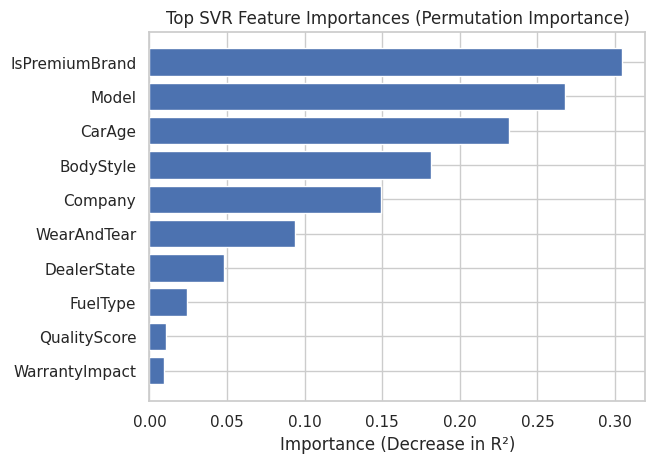

In [ ]:
top_n = 10
top_features = importance_df.head(top_n)

plt.figure()
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.title("Top SVR Feature Importances (Permutation Importance)")
plt.xlabel("Importance (Decrease in R²)")
plt.show()

## Model Prediction

In [ ]:
# Step 1 — Save Your Trained Model
import joblib

# Save the actual best trained model pipeline, which is gbr_best
joblib.dump(svr_best, "car_price_model.pkl")

['car_price_model.pkl']

In [ ]:
# Step 2 — Load Model Later

import joblib

model = joblib.load("car_price_model.pkl")

In [ ]:
# Step 3 — Prepare New Input Data
import pandas as pd
import numpy as np

sample_data_input = {
    "Kilometer": [42000],
    "ModelYear": [2018],
    "Warranty": [1],
    "QualityScore": [7.8],
    "Company": ["HYUNDAI"],
    "FuelType": ["PETROL"],
    "BodyStyle": ["HATCHBACK"],
    "TransmissionType": ["MANUAL"],
    "Model": ["I10"], # Added a sample model for HYUNDAI
    "Owner": ["1ST OWNER"], # Added a sample owner
    "DealerState": ["KARNATAKA"] # Added a sample dealer state
}

sample = pd.DataFrame(sample_data_input)

# Re-create engineered features for the sample data
current_year = pd.Timestamp.now().year
sample['CarAge'] = current_year - sample['ModelYear']

premium_brands = ['BMW', 'MERCEDES BENZ', 'AUDI', 'TOYOTA'] # Define premium_brands again
sample['IsPremiumBrand'] = sample['Company'].isin(premium_brands).astype(int)

sample['WarrantyImpact'] = sample['Warranty'] * sample['CarAge']
sample['UsageIntensity'] = sample['Kilometer'] / (sample['CarAge'] + 1)
sample['WearAndTear'] = sample['CarAge'] * np.log1p(sample['Kilometer'])

# Ensure TransmissionType is normalized as done during training
def clean_transmission(df_sample):
    if 'TransmissionType' not in df_sample.columns:
        return df_sample
    mapping = {
        'M': 'MANUAL',
        'MANUAL': 'MANUAL',
        'A': 'AUTOMATIC',
        'AUTOMATIC': 'AUTOMATIC',
        'AUOTMATIC': 'AUTOMATIC',   # typo fix
        'CVT': 'AUTOMATIC'
    }
    df_sample['TransmissionType'] = df_sample['TransmissionType'].replace(mapping)
    return df_sample

sample = clean_transmission(sample)

# Fill UNKNOWN for TransmissionType as done during training
if 'TransmissionType' in sample.columns:
    sample['TransmissionType'] = sample['TransmissionType'].fillna('UNKNOWN')

# IMPORTANT: Ensure the sample DataFrame has the exact same columns as X and in the same order
# Drop ModelYear from sample, as it's used to create CarAge but not included in final features X
sample = sample.drop(columns=['ModelYear'], errors='ignore')

# Ensure all columns from X are in sample, and reorder sample columns to match X
# (Assuming X.columns is available from the training phase)
missing_cols_in_sample = set(X.columns) - set(sample.columns)
for col in missing_cols_in_sample:
    sample[col] = None # Or appropriate default value if context allows

sample = sample[X.columns]


In [ ]:
# Step 4 — Predict Price
import numpy as np

log_pred = model.predict(sample)
price_pred = np.expm1(log_pred)

print("Predicted Price (Lakhs):", price_pred[0])

Predicted Price (Lakhs): 6.0931699859041855
